In [509]:
import plotly.io as pio

pio.kaleido.scope.default_format = "png"

AttributeError: 'NoneType' object has no attribute 'default_format' and no __dict__ for setting new attributes

In [ ]:
fig.write_image("reports/nav_trend.png")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [ ]:
fig.write_image("reports/nav_trend.png")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [ ]:
import os

os.makedirs("reports", exist_ok=True)
print("Reports folder ready")

Reports folder ready


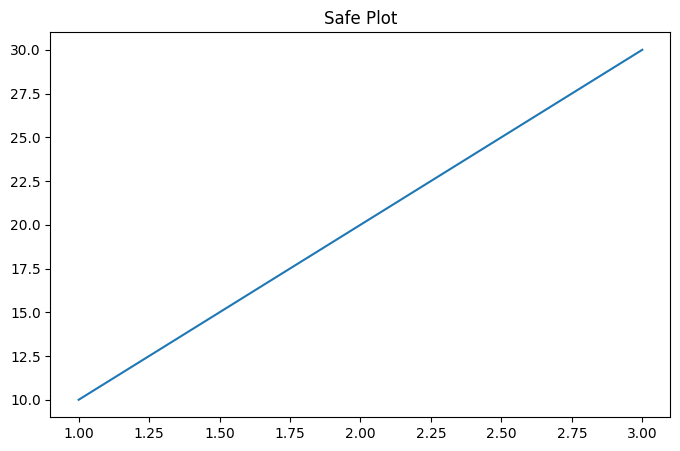

In [ ]:
if len(tx) > 0:
    plt.figure(figsize=(8,5))
    plt.plot([1,2,3], [10,20,30])
    plt.title("Safe Plot")
    plt.show()
else:
    print("No data")

In [ ]:
import plotly.express as px

if not nav.empty:
    fig = px.line(nav, x="date", y="nav", color="amfi_code")
    fig.show()
else:
    print("No data available for plotting")

In [ ]:
print(nav.head())
print(nav.columns)

  amfi_code        date  nav
0    FUND_A  2024-01-01  100
1    FUND_A  2024-01-02  101
2    FUND_A  2024-01-03  102
3    FUND_A  2024-01-04  103
4    FUND_A  2024-01-05  104
Index(['amfi_code', 'date', 'nav'], dtype='str')


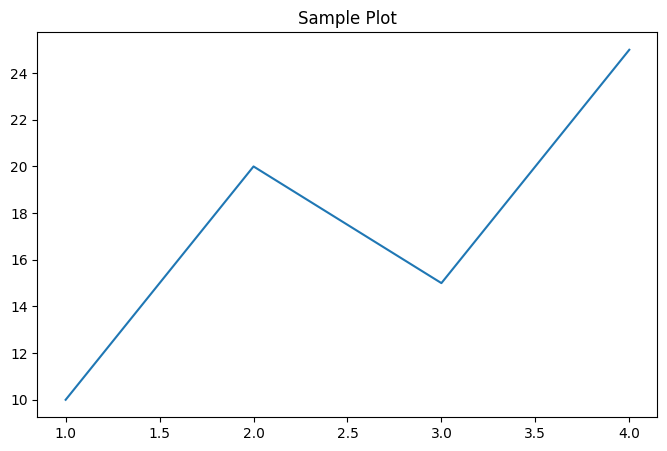

In [ ]:
plt.figure(figsize=(8,5))

plt.plot([1,2,3,4], [10,20,15,25])

plt.title("Sample Plot")

plt.savefig("reports/sample.png", bbox_inches="tight")
plt.show()

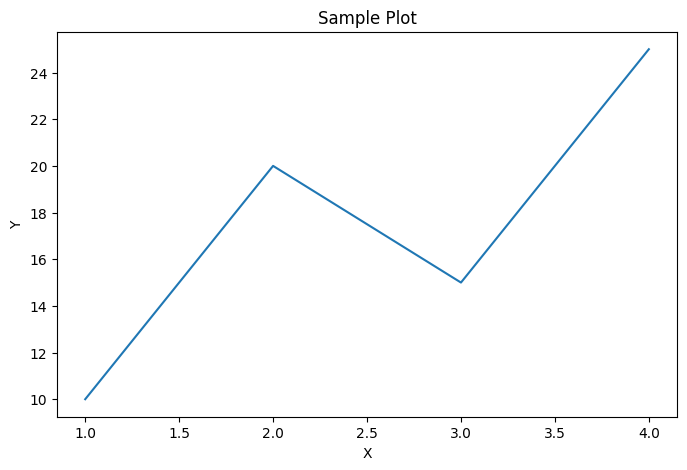

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot([1,2,3,4], [10,20,15,25])  # actual data

plt.title("Sample Plot")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [ ]:
plt.savefig("reports/aum.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
fig.write_image("reports/nav_trend.png")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [ ]:
import os

os.makedirs("reports", exist_ok=True)
print("reports folder created")

reports folder created


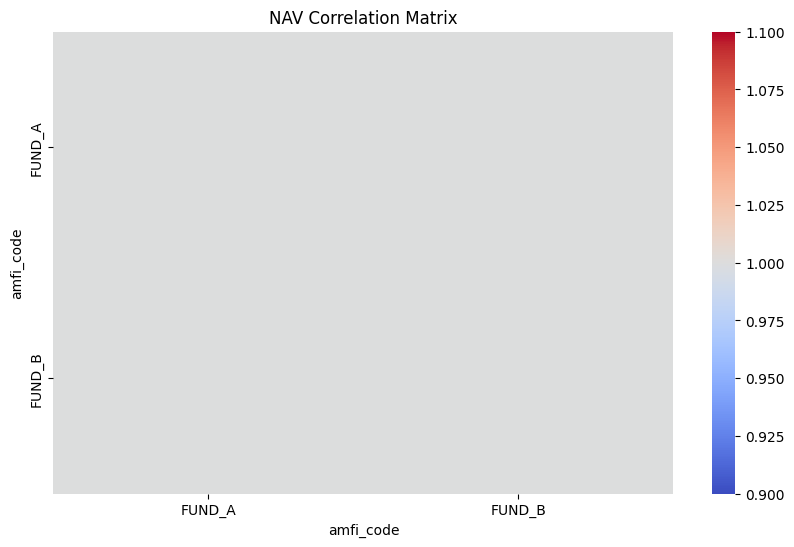

In [ ]:
pivot = nav.pivot_table(index="date", columns="amfi_code", values="nav")
corr = pivot.pct_change().corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("NAV Correlation Matrix")
plt.show()

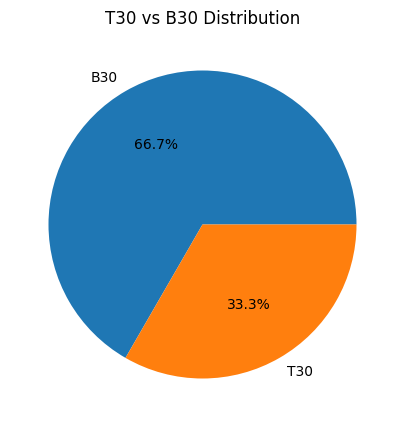

In [ ]:
tx["city_tier"] = np.random.choice(["T30", "B30"], len(tx))

tier_dist = tx["city_tier"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(tier_dist, labels=tier_dist.index, autopct="%1.1f%%")
plt.title("T30 vs B30 Distribution")
plt.show()

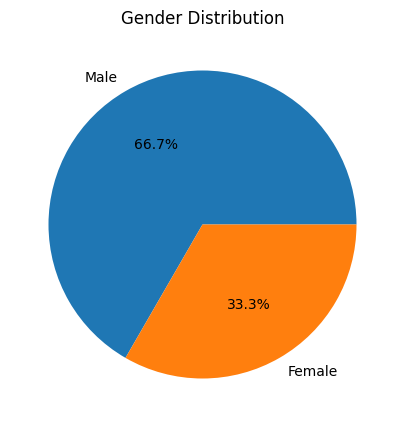

In [ ]:
tx["gender"] = np.random.choice(["Male", "Female"], len(tx))

gender_dist = tx["gender"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(gender_dist, labels=gender_dist.index, autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

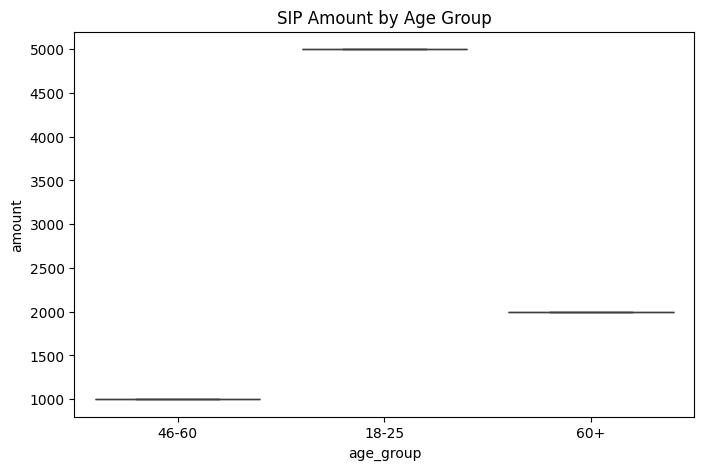

In [ ]:
tx["age_group"] = np.random.choice(age_groups, len(tx))

plt.figure(figsize=(8,5))
sns.boxplot(data=tx, x="age_group", y="amount")
plt.title("SIP Amount by Age Group")
plt.show()

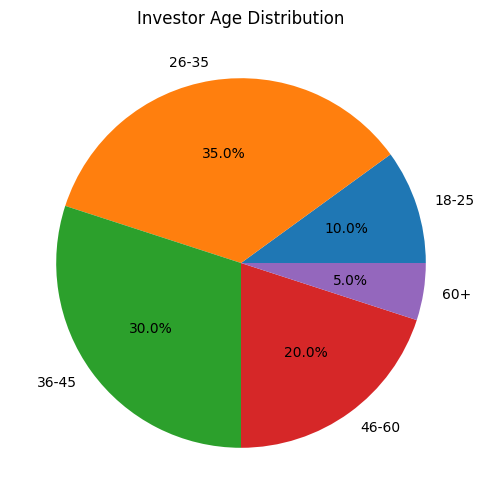

In [ ]:
age_groups = ["18-25", "26-35", "36-45", "46-60", "60+"]
values = [10, 35, 30, 20, 5]

plt.figure(figsize=(6,6))
plt.pie(values, labels=age_groups, autopct="%1.1f%%")
plt.title("Investor Age Distribution")
plt.show()

In [ ]:
labels = ["Equity", "Debt", "Hybrid", "Other"]
values = [55, 25, 15, 5]

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=0.5)])
fig.update_layout(title="Sector Allocation")
fig.show()

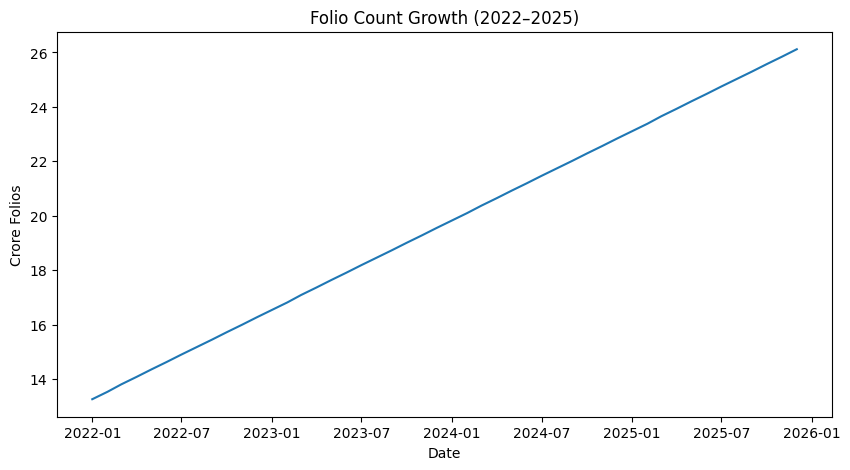

In [ ]:
folio = pd.DataFrame({
    "date": pd.date_range("2022-01-01", "2025-12-01", freq="MS"),
    "folios": np.linspace(13.26, 26.12, 48)
})

plt.figure(figsize=(10,5))
plt.plot(folio["date"], folio["folios"])
plt.title("Folio Count Growth (2022–2025)")
plt.xlabel("Date")
plt.ylabel("Crore Folios")
plt.show()

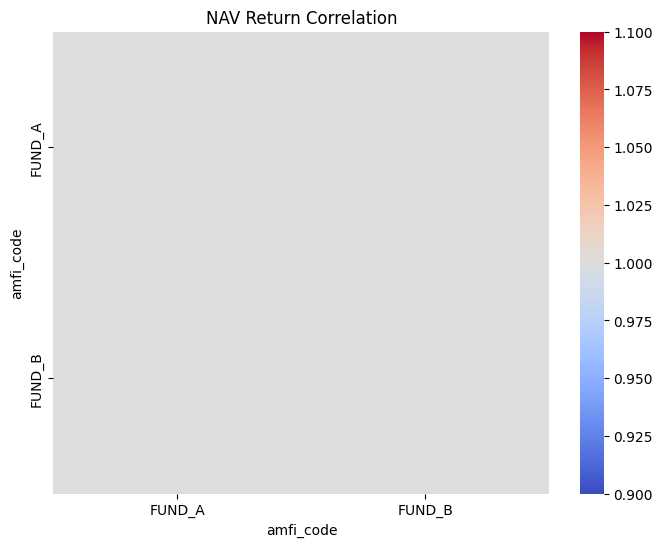

In [ ]:
pivot = nav.pivot_table(index="date", columns="amfi_code", values="nav")
returns = pivot.pct_change().corr()

plt.figure(figsize=(8,6))
sns.heatmap(returns, cmap="coolwarm", annot=False)
plt.title("NAV Return Correlation")
plt.show()

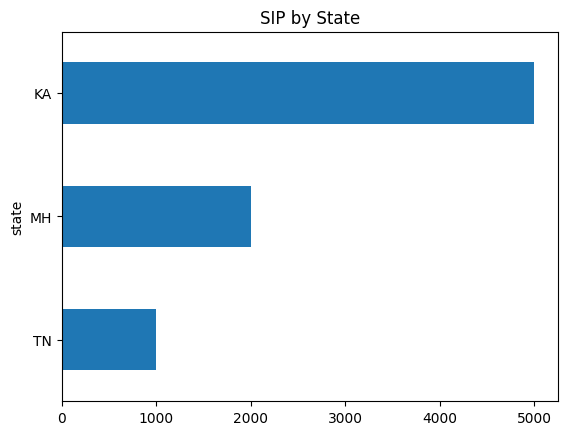

In [ ]:
state_sum = tx.groupby("state")["amount"].sum().sort_values()

state_sum.plot(kind="barh", title="SIP by State")
plt.show()

In [ ]:
fig.add_annotation(
    x="2025-12",
    y=sip_monthly["amount"].max(),
    text="₹31,002 Cr Peak",
    showarrow=True
)

In [ ]:
sip = tx[tx["transaction_type"] == "SIP"]
sip["month"] = sip["date"].dt.to_period("M").astype(str)

sip_monthly = sip.groupby("month")["amount"].sum().reset_index()

fig = px.line(
    sip_monthly,
    x="month",
    y="amount",
    title="Monthly SIP Inflow Trend"
)

fig.show()

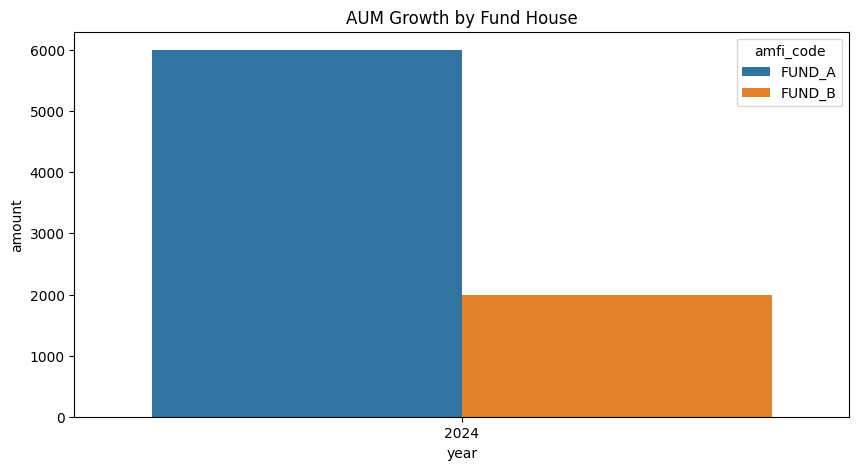

In [ ]:
tx["year"] = tx["date"].dt.year

aum = tx.groupby(["year", "amfi_code"])["amount"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=aum, x="year", y="amount", hue="amfi_code")
plt.title("AUM Growth by Fund House")
plt.show()

In [ ]:
tx = pd.read_csv(os.path.join("data", "processed", "investor_transactions_cleaned.csv"))
tx["date"] = pd.to_datetime(tx["date"])

tx.head()

,amfi_code,investor_id,date,transaction_type,amount,state,kyc_status
0,FUND_A,I1,2024-01-01,SIP,1000,TN,YES
1,FUND_A,I2,2024-01-02,LUMPSUM,5000,KA,YES
2,FUND_B,I3,2024-01-03,REDEMPTION,2000,MH,VERIFIED


In [ ]:
fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.2,
    annotation_text="Bull Run 2023"
)

fig.add_vrect(
    x0="2024-01-01", x1="2024-12-31",
    fillcolor="red", opacity=0.2,
    annotation_text="Market Correction 2024"
)

In [ ]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (2022–2026)"
)

fig.show()

In [ ]:
nav_path = os.path.join("data", "processed", "nav_history_cleaned.csv")

nav = pd.read_csv(nav_path)
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,FUND_A,2024-01-01,100
1,FUND_A,2024-01-02,101
2,FUND_A,2024-01-03,102
3,FUND_A,2024-01-04,103
4,FUND_A,2024-01-05,104


In [ ]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

BASE_DIR = r"d:\mutual_fund_analytics"
os.chdir(BASE_DIR)

print("Working directory:", os.getcwd())

Working directory: d:\mutual_fund_analytics


In [ ]:
os.path.join("data", "raw", "file.csv")

'data\\raw\\file.csv'

In [ ]:
import plotly.express as px

fig = px.line(nav, x="date", y="nav", color="amfi_code",
              title="NAV Trend Analysis (2022–2026)")

fig.show()

In [ ]:
if not os.path.exists(nav_path):
    print("Clean file missing — regenerating...")

    raw = pd.read_csv(os.path.join("data", "raw", "nav_history.csv"))

    raw["date"] = pd.to_datetime(raw["date"])
    raw = raw.sort_values(["amfi_code", "date"])
    raw = raw.drop_duplicates()
    raw = raw[raw["nav"] > 0]

    os.makedirs(os.path.join("data", "processed"), exist_ok=True)
    raw.to_csv(nav_path, index=False)

    print("Clean file recreated")

In [ ]:
nav_path = os.path.join("data", "processed", "nav_history_cleaned.csv")

nav = pd.read_csv(nav_path)
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,FUND_A,2024-01-01,100
1,FUND_A,2024-01-02,101
2,FUND_A,2024-01-03,102
3,FUND_A,2024-01-04,103
4,FUND_A,2024-01-05,104


In [ ]:
import os
import pandas as pd

BASE_DIR = r"d:\mutual_fund_analytics"
os.chdir(BASE_DIR)

print("Working directory:", os.getcwd())

Working directory: d:\mutual_fund_analytics


In [ ]:
import pandas as pd

nav = pd.read_csv("data/raw/nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])
nav = nav.drop_duplicates()
nav = nav[nav["nav"] > 0]

os.makedirs("data/processed", exist_ok=True)

nav.to_csv("data/processed/nav_history_cleaned.csv", index=False)

print("Pipeline rebuilt successfully")

Pipeline rebuilt successfully


In [ ]:
import os

print(os.listdir("."))
print(os.listdir("data/raw"))

['.git', '.gitignore', '.vscode', 'amfi_validation.py', 'analysis.py', 'dashboard', 'data', 'data_ingestion', 'fund_master_explore.py', 'hdfc_top100_live.csv', 'live_nav_fetch.py', 'New folder', 'notebooks', 'performance.py', 'README.md', 'READMEE.md', 'reports', 'requirements.txt', 'sql', 'visualization.py']
['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count (2).csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'all_mutual_funds.csv', 'hdfc_top100.csv', 'hdfc_top100_clean.csv', 'investor_transactions.csv', 'multi_scheme_nav.csv', 'nav_history.csv', 'scheme_performance.csv']


In [ ]:
import pandas as pd

nav = pd.read_csv("data/raw/nav_history.csv")

In [ ]:
import os

BASE_DIR = r"d:\mutual_fund_analytics"
os.chdir(BASE_DIR)

print("Working directory set to:", os.getcwd())

Working directory set to: d:\mutual_fund_analytics


In [ ]:
import os

for root, dirs, files in os.walk("d:\\"):
    for file in files:
        if "nav" in file.lower():
            print(os.path.join(root, file))

d:\everyversions\dynamicgraph\vite-project\node_modules\antd\es\steps\style\nav.d.ts
d:\everyversions\dynamicgraph\vite-project\node_modules\antd\es\steps\style\nav.js
d:\everyversions\dynamicgraph\vite-project\node_modules\antd\lib\steps\style\nav.d.ts
d:\everyversions\dynamicgraph\vite-project\node_modules\antd\lib\steps\style\nav.js
d:\everyversions\dynamicgraph\vite-project\node_modules\caniuse-lite\data\features\nav-timing.js
d:\everyversions\final\vite-project\node_modules\antd\es\steps\style\nav.d.ts
d:\everyversions\final\vite-project\node_modules\antd\es\steps\style\nav.js
d:\everyversions\final\vite-project\node_modules\antd\lib\steps\style\nav.d.ts
d:\everyversions\final\vite-project\node_modules\antd\lib\steps\style\nav.js
d:\everyversions\final\vite-project\node_modules\caniuse-lite\data\features\nav-timing.js
d:\everyversions\weakness\vite-project\node_modules\antd\es\steps\style\nav.d.ts
d:\everyversions\weakness\vite-project\node_modules\antd\es\steps\style\nav.js
d:\ev

In [ ]:
import os

print(os.getcwd())
print(os.listdir(".."))

d:\mutual_fund_analytics
['$RECYCLE.BIN', 'Config.Msi', 'everyversions', 'farewell', 'mutual_fund_analytics', 'new antigravity', 'olaama models', 'oracle', 'python program 1.py', 'Python-3.12.13', 'React Programs', 'reshh', 'retainX', 'retainX - Copy', 'retainX - Copy.zip', 'retention', 'SkillUp', 'System Volume Information']


In [ ]:
nav = pd.read_csv("../data/raw/nav_history.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/nav_history.csv'

In [ ]:
import pandas as pd

nav = pd.read_csv("data/raw/nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])
nav = nav.drop_duplicates()
nav = nav[nav["nav"] > 0]

nav.to_csv("data/processed/nav_history_cleaned.csv", index=False)

print("Clean file created successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/nav_history.csv'

In [ ]:
import os

os.makedirs("data/processed", exist_ok=True)

In [ ]:
nav = pd.read_csv("data/processed/nav_history_cleaned.csv")
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(nav, x="date", y="nav", color="amfi_code",
              title="Daily NAV Trend (2022–2026)")

fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/nav_history_cleaned.csv'

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt